# POWERLIFT PREDICTOR
### Predict the score for any one of the following three lifts, based on the other two:
- Squat
- Bench Press
- Deadlift

#### This Data Science analysis is performed on a [Powerlifting Dataset](https://www.kaggle.com/datasets/open-powerlifting/powerlifting-database) (pre-filtered for memory usage purposes), to perform Data preprocessing, Data cleaning, Feature Engineering, Exploratory Data Analysis (EDA), Data Visualization, Predictive Modeling, Model Evaluation, and Deployment

In [144]:
# IMPORTING LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [145]:
# LOADING DATASET

FILE_PATH = "./powerlifting-dataset.csv"

pldf_raw = pd.read_csv(FILE_PATH, index_col=0)

print("DATASET LOADED")
pldf_raw.shape

DATASET LOADED


(3043013, 6)

#### The raw dataset will remain unaltered and simply cloned into a new "working" dataframe 

In [146]:
# COPYING RAW DATASET INTO WORKING DATAFRAME

df = pldf_raw.copy()

df.head()

,Sex,Age,BodyweightKg,Best3SquatKg,Best3BenchKg,Best3DeadliftKg
0,F,33.0,58.30,80.0,60.0,107.5
1,F,43.0,73.10,105.0,67.5,110.0
2,M,15.5,67.40,100.0,62.5,105.0
3,M,35.0,66.65,137.5,122.5,170.0
4,M,26.5,72.45,90.0,50.0,125.0


#### Formatting the columns allows for easy reading and handling

In [147]:
# RENAMING AND FORMAT COLUMNS

df.rename(
    columns = {
        "BodyweightKg": "WEIGHT",
        "Best3SquatKg": "SQUAT",
        "Best3BenchKg": "BENCH",
        "Best3DeadliftKg": "DEADLIFT"
    },
    inplace = True
)
df.rename(columns = lambda col: col.upper(), inplace=True)
df.head(5)

,SEX,AGE,WEIGHT,SQUAT,BENCH,DEADLIFT
0,F,33.0,58.30,80.0,60.0,107.5
1,F,43.0,73.10,105.0,67.5,110.0
2,M,15.5,67.40,100.0,62.5,105.0
3,M,35.0,66.65,137.5,122.5,170.0
4,M,26.5,72.45,90.0,50.0,125.0


#### After formatting the columns, each feature will be examined individually, starting with the descriptions (distrbutions, counts, values, etc)

In [148]:
# CHECKING "SEX" VALUES AND COUNTS

print(df["SEX"].value_counts(dropna=False))

SEX
M     2290122
F      752828
Mx         63
Name: count, dtype: int64


The "SEX" value "Mx" does not correspond to either Male or Female. Its purpose is unclear.
This issue can be approached by:
- Imputing "Mx" values -- using KNN or alternative
- Omitting the rows: losing 63 values (from over 3 million)
- Omitted the SEX column: losing an entire attribute due to a few unusual values

In [149]:
# CHECKING "AGE" VALUES AND COUNTS

n_null_age = df[pd.isna(df["AGE"])].shape[0]
pct_null_age = np.round(n_null_age/df.shape[0]*100, 2)

print("Amount of missing AGE values:")
print(f"{n_null_age} of {df.shape[0]} ({pct_null_age}%)")
print('\n')

age_description = df["AGE"].describe().round().astype(int)
print(age_description)

Amount of missing AGE values:
1070337 of 3043013 (35.17%)


count    1972676
mean          31
std           13
min            0
25%           20
50%           28
75%           38
max           98
Name: AGE, dtype: int64


The AGE column seems to have values of 0. 
Similar to the issue with the SEX column, this issue has a few possible approaches:
- Impute the invalid values
- Omit the rows
- Omit the entire AGE column

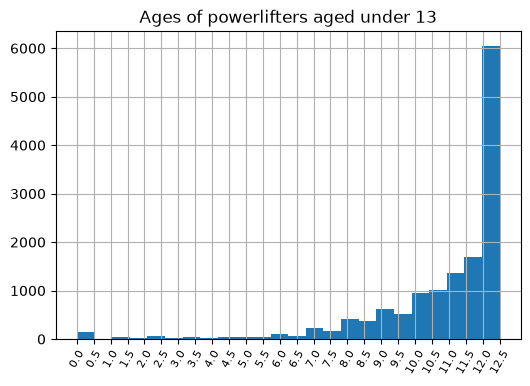

In [150]:
# PLOTTING UNDERAGE POWERLIFTERS' AGES (DISTRIBUTION)

young_kids = df[df["AGE"] < 13]

plt.figure()
plt.xticks([x/2 for x in range(0, 26, 1)])
plt.title("Ages of powerlifters aged under 13")

young_kids["AGE"].hist(
    xlabelsize=8,
    xrot=60,
    figsize=(6, 4),
    bins=24     # bins set to double that of total, to capture half-year increment (ex: 11.5)
)
plt.show()

There are also alarmingly low values in this column, even as low as 0.5!
This has to be a data entry error.
Nearly 14 thousand rows are from children under 13.
For ethical purposes, these may need to be omitted entirely.

Further investigation is due to determine how much of these are errors in data entry.
There is a notable increase in count from x=10 onwards, so ages below that level must be prioritized for data cleaning.

In [151]:
# CHECKING "WEIGHT" VALUES AND 5-NUMBER SUMMARY

df["WEIGHT"].describe().round(2)

count    3004645.00
mean          84.17
std           22.63
min           10.00
25%           67.20
50%           81.95
75%           98.79
max          300.00
Name: WEIGHT, dtype: float64

The WEIGHT column seems to contain some values which are alarmingly low and alarmingly high.
The validity of these values must be confirmed via further analysis.

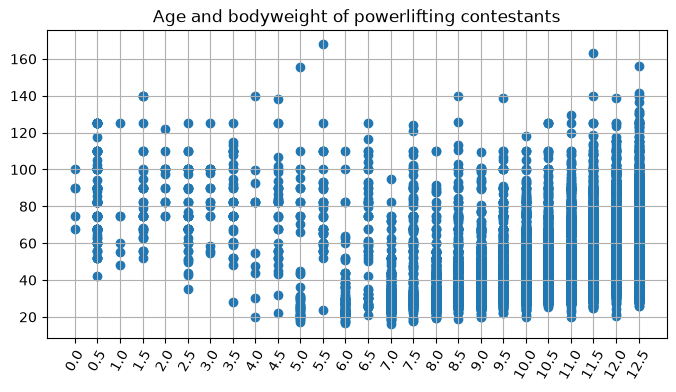

In [152]:
# COMPARING BODYWEIGHTS OF CONTESTANTS OF DIFFERENT AGES

plt.figure(figsize = (8, 4))
plt.xticks(
    ticks = [x/2 for x in range(0, 26, 1)],
    rotation = 60
)
plt.title("Age and bodyweight of powerlifting contestants")
plt.scatter(x=young_kids["AGE"], y=young_kids["WEIGHT"])
plt.grid(True)
plt.show()

Not only are extremely low AGE values guaranteed to be faulty entries, but many individuals have unrealistic WEIGHT values for their age (ex: a 6-year-old weighing 170kg, AKA ~374 lbs).
These values need to be handled by imputation or omission.

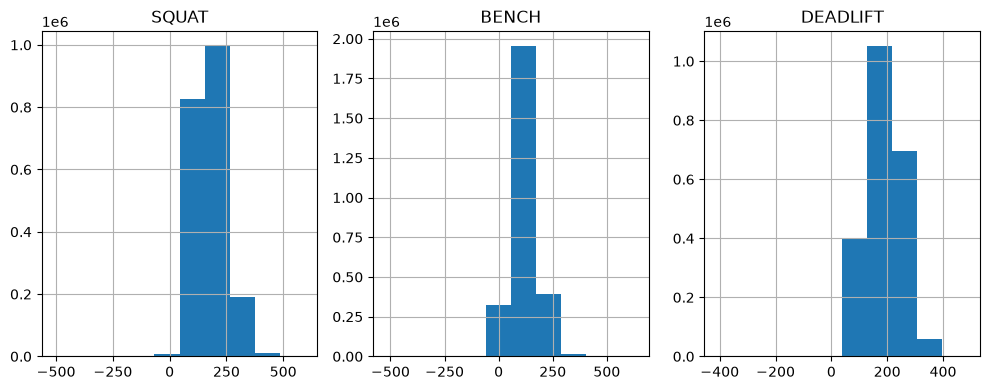

In [164]:
# ANALYZING AND PLOTTING LIFT SCORES

lifts = ["SQUAT", "BENCH", "DEADLIFT"]

fig, axes = plt.subplots(ncols=len(lifts), figsize=(10, 4))

for lift,ax in zip(lifts, axes):
    ax.hist(df[lift])
    ax.set_title(lift)
    ax.grid(True)

plt.tight_layout()
plt.show()


The presence of lift scores below zero indicates one or more of the followinga:
- errors in data entry
- scoring convention (failed attempts are recorded as negative)

This formatting system is leading to data science issues which can be fixed with either:
- replacing the invalid scores via imputation
- omitting the rows containing the invalid scores